In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("force2020_data_unsupervised_learning.csv")
curves = ["RHOB", "GR", "NPHI", "PEF", "DTC"]
units = {"RHOB": "g/cc", "GR": "API", "NPHI": "v/v", "PEF": "b/e", "DTC": "us/ft"}

print("Rows:", len(df))
print("Depth:", df["DEPTH_MD"].min(), "-", df["DEPTH_MD"].max(), "m")
print("Step:", df["DEPTH_MD"].diff().median(), "m")
df.head()


Rows: 18270
Depth: 494.528 - 3272.024000000001 m
Step: 0.15200000000004366 m


,RHOB,GR,DEPTH_MD,NPHI,PEF,DTC
0,1.884186,80.200851,494.528,NaN,20.915468,161.131180
1,1.889794,79.262886,494.680,NaN,19.383013,160.603470
2,1.896523,74.821999,494.832,NaN,22.591518,160.173615
3,1.891913,72.878922,494.984,NaN,32.191910,160.149429
4,1.880034,71.729141,495.136,NaN,38.495632,160.128342


In [3]:
all_cols = ["DEPTH_MD"] + curves
all_units = {"DEPTH_MD": "m", **units}

before = pd.DataFrame({
    "unit": pd.Series(all_units),
    "count": df[all_cols].count(),
    "missing": df[all_cols].isna().sum(),
    "missing %": (df[all_cols].isna().mean() * 100).round(1),
    "min": df[all_cols].min().round(2),
    "25%": df[all_cols].quantile(0.25).round(2),
    "median": df[all_cols].median().round(2),
    "75%": df[all_cols].quantile(0.75).round(2),
    "max": df[all_cols].max().round(2),
    "std": df[all_cols].std().round(2),
}).loc[all_cols]
before


,unit,count,missing,missing %,min,25%,median,75%,max,std
DEPTH_MD,m,18270,0,0.0,494.53,1188.75,1882.97,2577.80,3272.02,801.94
RHOB,g/cc,18270,0,0.0,1.40,1.96,2.06,2.38,2.93,0.30
GR,API,18270,0,0.0,6.19,43.87,66.78,81.54,499.02,28.64
NPHI,v/v,14032,4238,23.2,0.02,0.32,0.45,0.51,0.80,0.13
PEF,b/e,16440,1830,10.0,1.01,2.32,2.79,4.27,66.03,2.56
DTC,us/ft,18189,81,0.4,55.73,90.88,141.30,148.05,175.95,30.62


In [4]:
def missing_blocks(col):
    blank = df[col].isna()
    group = (blank != blank.shift()).cumsum()
    blocks = df[blank].groupby(group[blank]).agg(
        top=("DEPTH_MD", "min"), bottom=("DEPTH_MD", "max"), rows=("DEPTH_MD", "size"))
    blocks["length (m)"] = (blocks["bottom"] - blocks["top"] + 0.152).round(2)
    return blocks.reset_index(drop=True)

for col in curves:
    blocks = missing_blocks(col)
    if len(blocks) == 0:
        print(f"{col}: no missing values\n")
        continue
    print(f"{col}: {df[col].isna().sum()} missing in {len(blocks)} block(s)")
    print(blocks.round(2).to_string(index=False), "\n")


RHOB: no missing values

GR: no missing values

NPHI: 4238 missing in 1 block(s)
   top  bottom  rows  length (m)
494.53 1138.55  4238      644.18 

PEF: 1830 missing in 1 block(s)
    top  bottom  rows  length (m)
2994.02 3272.02  1830      278.16 

DTC: 81 missing in 1 block(s)
    top  bottom  rows  length (m)
3259.86 3272.02    81       12.31 



**Missing data result:** each curve's blanks form one continuous block — NPHI 494.5–1138.6 m (644 m), PEF
2994.0–3272.0 m (278 m), DTC 3259.9–3272.0 m (12 m). No short holes, so nothing to fill. These sections were
never logged and stay blank. All five curves exist together only in **1138.7–2993.9 m**.


In [5]:
limits = {"RHOB": (1.5, 3.0), "GR": (0, 250), "NPHI": (-0.15, 1.0), "PEF": (0, 10), "DTC": (40, 190)}

def flagged_blocks(mask):
    group = (mask != mask.shift()).cumsum()
    blocks = df[mask].groupby(group[mask]).agg(
        top=("DEPTH_MD", "min"), bottom=("DEPTH_MD", "max"), rows=("DEPTH_MD", "size"))
    return blocks.reset_index(drop=True).round(2)

out_of_range = {}
for col, (low, high) in limits.items():
    mask = (df[col] < low) | (df[col] > high)
    out_of_range[col] = mask
    if mask.sum() == 0:
        print(f"{col}: none outside {low}–{high} {units[col]}\n")
        continue
    blocks = flagged_blocks(mask)
    print(f"{col}: {mask.sum()} readings outside {low}–{high} {units[col]}, in {len(blocks)} stretch(es)")
    print(blocks.sort_values("rows", ascending=False).head(8).to_string(index=False), "\n")


RHOB: 976 readings outside 1.5–3.0 g/cc, in 26 stretch(es)
    top  bottom  rows
 993.24 1011.78   123
 967.40  982.75   102
 502.74  516.42    91
 954.48  966.64    81
1012.24 1023.79    77
1042.94 1053.89    73
 892.62  903.10    70
 850.82  861.30    70 

GR: 9 readings outside 0–250 API, in 2 stretch(es)
    top  bottom  rows
2761.30 2762.37     8
2747.47 2747.47     1 

NPHI: none outside -0.15–1.0 v/v

PEF: 225 readings outside 0–10 b/e, in 27 stretch(es)
    top  bottom  rows
1176.86 1188.56    78
 494.53  501.22    45
1173.97 1176.40    17
1216.83 1218.20    10
2190.54 2191.30     6
2757.50 2758.26     6
2736.98 2737.74     6
2731.36 2731.97     5 

DTC: none outside 40–190 us/ft



In [6]:
low_rhob = df[out_of_range["RHOB"]]

print("Low-RHOB readings:", len(low_rhob))
print("With PEF recorded:", low_rhob["PEF"].notna().sum())
print("\nPEF at those depths:")
print(low_rhob["PEF"].describe().round(2))
print("\nLow PEF (< 1.5, coal-like):", (low_rhob["PEF"] < 1.5).sum())
print("High PEF (> 5, washout-like):", (low_rhob["PEF"] > 5).sum())


Low-RHOB readings: 976
With PEF recorded: 976

PEF at those depths:
count    976.00
mean       1.07
std        0.22
min        1.01
25%        1.05
50%        1.05
75%        1.06
max        6.09
Name: PEF, dtype: float64

Low PEF (< 1.5, coal-like): 974
High PEF (> 5, washout-like): 2


In [7]:
spike_window = 7
spike_flags = {}
rows = []

for col in curves:
    spread = df[col].quantile(0.75) - df[col].quantile(0.25)
    local = df[col].rolling(window=spike_window, center=True, min_periods=spike_window // 2 + 1).median()
    mask = (df[col] - local).abs() > 0.5 * spread
    spike_flags[col] = mask
    blocks = flagged_blocks(mask)
    rows.append({"curve": col,
                 "spread (IQR)": round(spread, 3),
                 "spike limit": round(0.5 * spread, 3),
                 "spikes": int(mask.sum()),
                 "stretches": len(blocks),
                 "longest (rows)": int(blocks["rows"].max()) if len(blocks) else 0})

pd.DataFrame(rows).set_index("curve")


,spread (IQR),spike limit,spikes,stretches,longest (rows)
curve,,,,,
RHOB,0.419,0.209,8,6,2
GR,37.676,18.838,9,5,3
NPHI,0.191,0.095,19,15,3
PEF,1.947,0.973,272,156,9
DTC,57.165,28.583,4,4,1


In [8]:
flat_window = 13
flat_flags = {}
rows = []

for col in curves:
    spread = df[col].quantile(0.75) - df[col].quantile(0.25)
    wobble = df[col].rolling(window=flat_window, center=True, min_periods=flat_window).std()
    mask = wobble < 0.01 * spread
    flat_flags[col] = mask
    blocks = flagged_blocks(mask)
    blocks = blocks[blocks["rows"] >= flat_window]
    in_model = mask & df["DEPTH_MD"].between(1138.7, 2993.9)
    rows.append({"curve": col,
                 "flat readings": int(mask.sum()),
                 "stretches (2 m+)": len(blocks),
                 "longest (m)": round(blocks["rows"].max() * 0.152, 1) if len(blocks) else 0,
                 "inside clustering interval": int(in_model.sum())})

pd.DataFrame(rows).set_index("curve")


,flat readings,stretches (2 m+),longest (m),inside clustering interval
curve,,,,
RHOB,504,11,8.1,92
GR,0,0,0.0,0
NPHI,0,0,0.0,0
PEF,704,14,16.6,0
DTC,4846,41,141.4,2310


      inside drop  5 m around it  change  change as % of spread
RHOB         1.89           1.90   -0.01                   -2.8
GR          68.64          77.34   -8.70                  -23.1
NPHI         0.48           0.50   -0.01                   -6.7
PEF          2.29           2.30   -0.01                   -0.6
DTC        132.86         148.68  -15.81                  -27.7


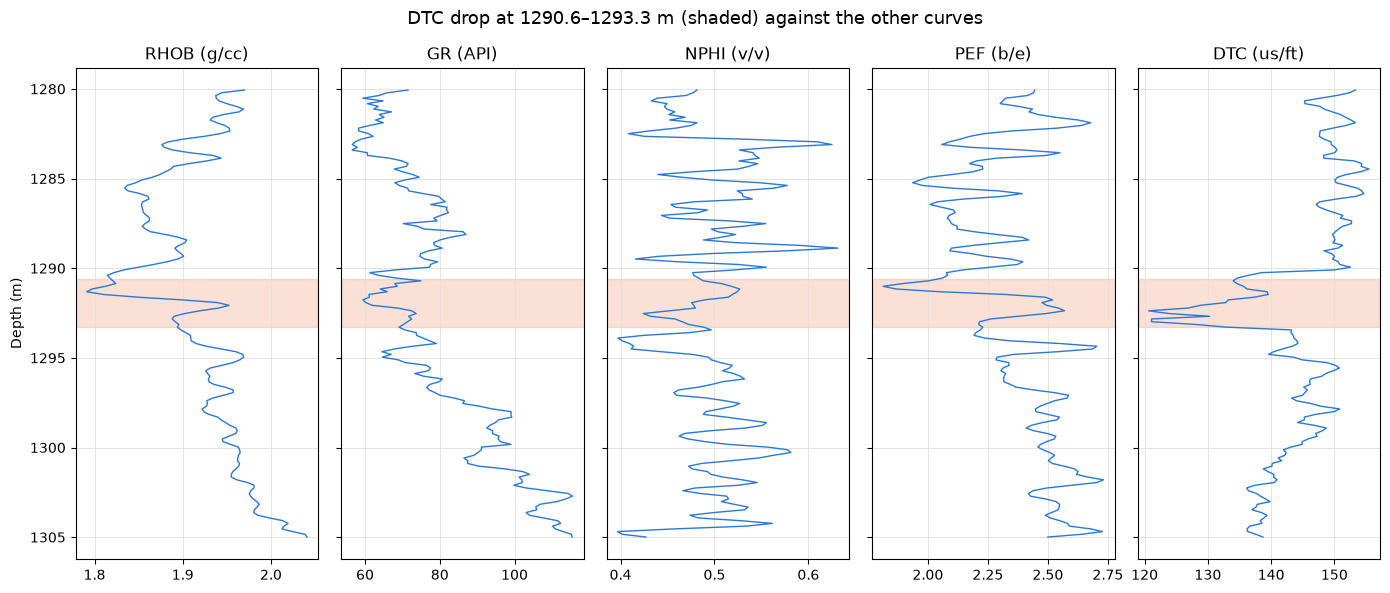

In [9]:
top, bottom = 1290.6, 1293.3
zone = df["DEPTH_MD"].between(top, bottom)
around = df["DEPTH_MD"].between(top - 5, top) | df["DEPTH_MD"].between(bottom, bottom + 5)

check = pd.DataFrame({
    "inside drop": df.loc[zone, curves].median(),
    "5 m around it": df.loc[around, curves].median(),
})
check["change"] = check["inside drop"] - check["5 m around it"]
spread = df[curves].quantile(0.75) - df[curves].quantile(0.25)
check["change as % of spread"] = (check["change"] / spread * 100).round(1)
print(check.round(2))

view = df["DEPTH_MD"].between(1280, 1305)
fig, axes = plt.subplots(1, len(curves), figsize=(14, 6), sharey=True)
for ax, col in zip(axes, curves):
    ax.plot(df.loc[view, col], df.loc[view, "DEPTH_MD"], color="#2a78d6", linewidth=1)
    ax.axhspan(top, bottom, color="#eb6834", alpha=0.2)
    ax.set_title(f"{col} ({units[col]})")
    ax.grid(color="#e1e0d9", linewidth=0.6)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
fig.suptitle(f"DTC drop at {top}–{bottom} m (shaded) against the other curves", fontsize=13)
plt.tight_layout()
plt.show()


In [10]:
clean = df.copy()

clean["flag_bad_hole"] = out_of_range["RHOB"]
clean["flag_pef_high"] = out_of_range["PEF"]
clean["flag_pef_spike"] = spike_flags["PEF"] & ~clean["flag_pef_high"] & ~clean["flag_bad_hole"]
clean["flag_dtc_frozen"] = flat_flags["DTC"]
clean["flag_gr_high"] = out_of_range["GR"]

clean.loc[clean["flag_bad_hole"], ["RHOB", "PEF", "DTC"]] = np.nan
clean.loc[clean["flag_pef_high"], "PEF"] = np.nan

pef_local = clean["PEF"].rolling(window=7, center=True, min_periods=4).median()
clean.loc[clean["flag_pef_spike"], "PEF"] = pef_local[clean["flag_pef_spike"]]

flag_cols = [col for col in clean.columns if col.startswith("flag_")]
clean[flag_cols].sum()


flag_bad_hole       976
flag_pef_high       225
flag_pef_spike      208
flag_dtc_frozen    4846
flag_gr_high          9
dtype: int64

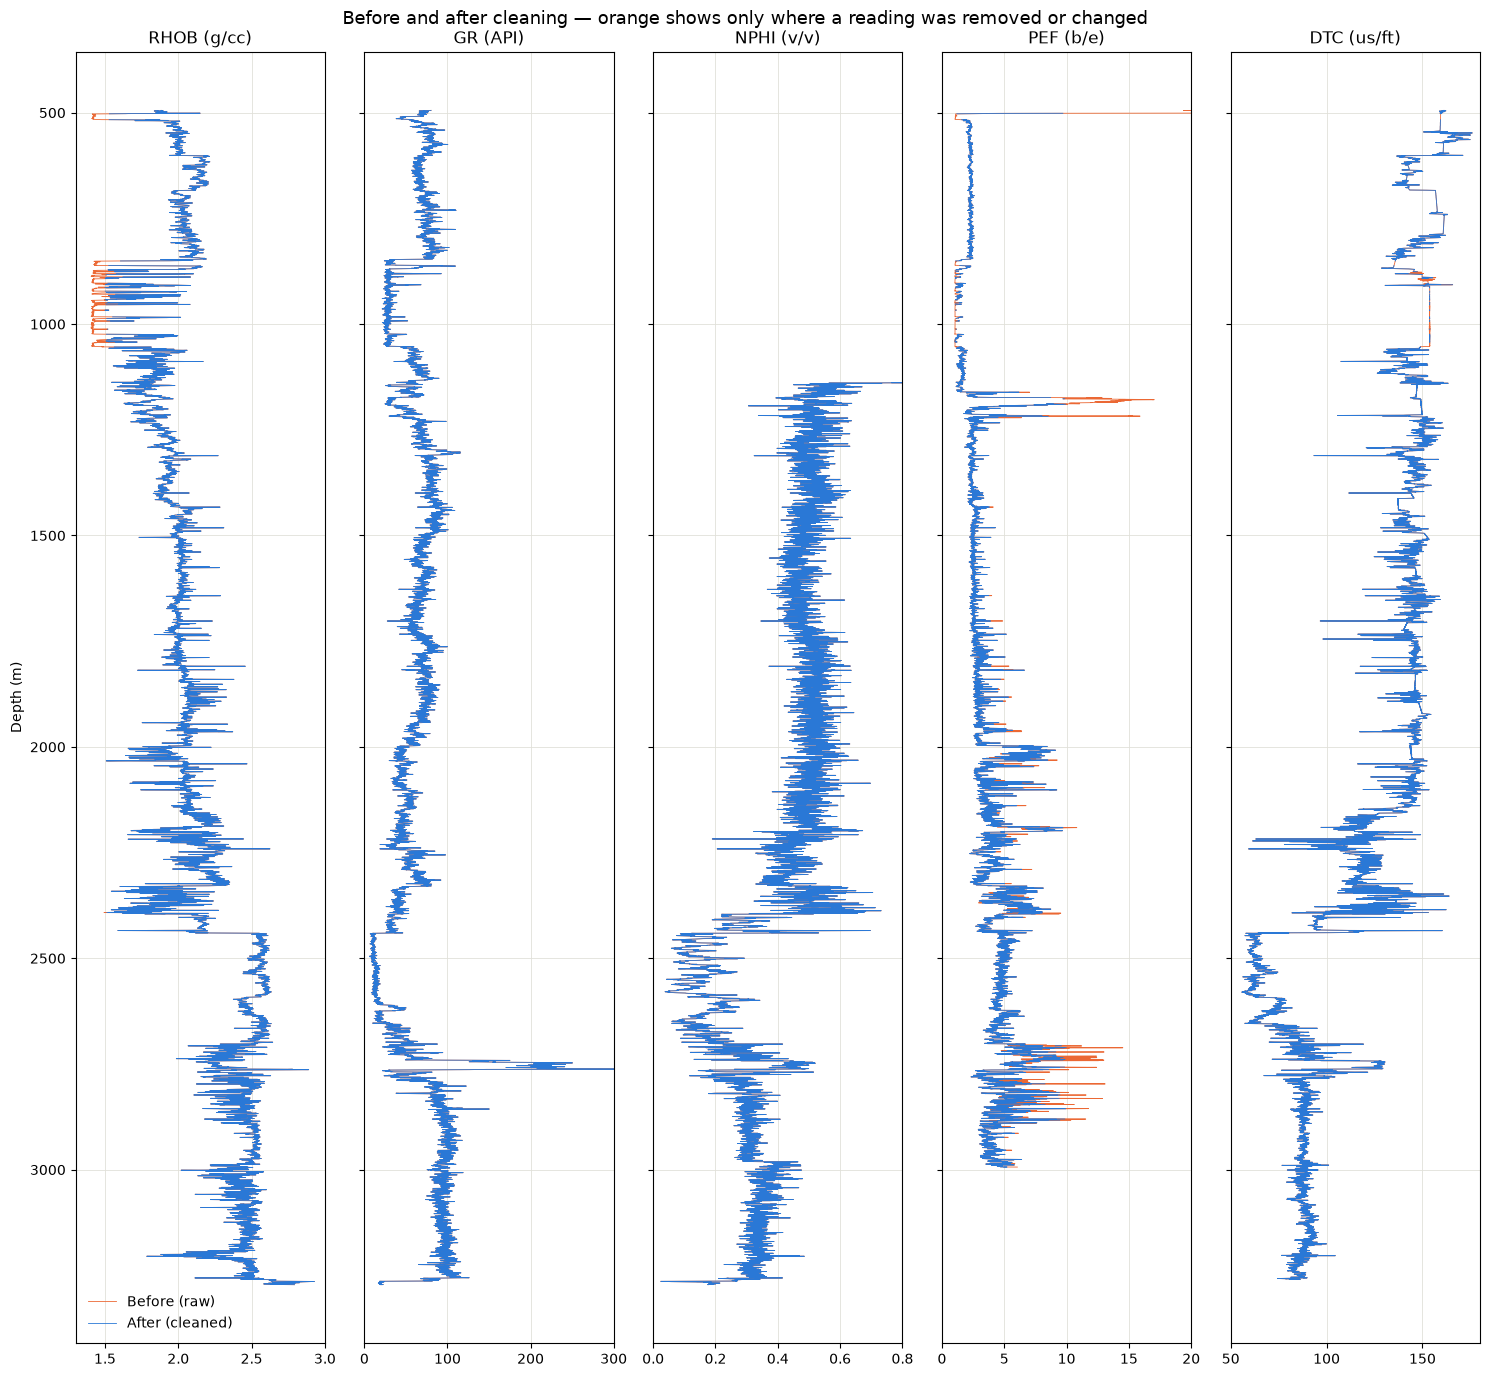

In [11]:
track_range = {"RHOB": (1.3, 3.0), "GR": (0, 300), "NPHI": (0, 0.8), "PEF": (0, 20), "DTC": (50, 180)}

fig, axes = plt.subplots(1, len(curves), figsize=(15, 14), sharey=True)
for ax, col in zip(axes, curves):
    ax.plot(df[col], df["DEPTH_MD"], color="#eb6834", linewidth=0.6, label="Before (raw)")
    ax.plot(clean[col], clean["DEPTH_MD"], color="#2a78d6", linewidth=0.6, label="After (cleaned)")
    ax.set_xlim(track_range[col])
    ax.set_title(f"{col} ({units[col]})")
    ax.grid(color="#e1e0d9", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
axes[0].legend(loc="lower left", frameon=False)
fig.suptitle("Before and after cleaning — orange shows only where a reading was removed or changed", fontsize=13)
plt.tight_layout()
plt.show()


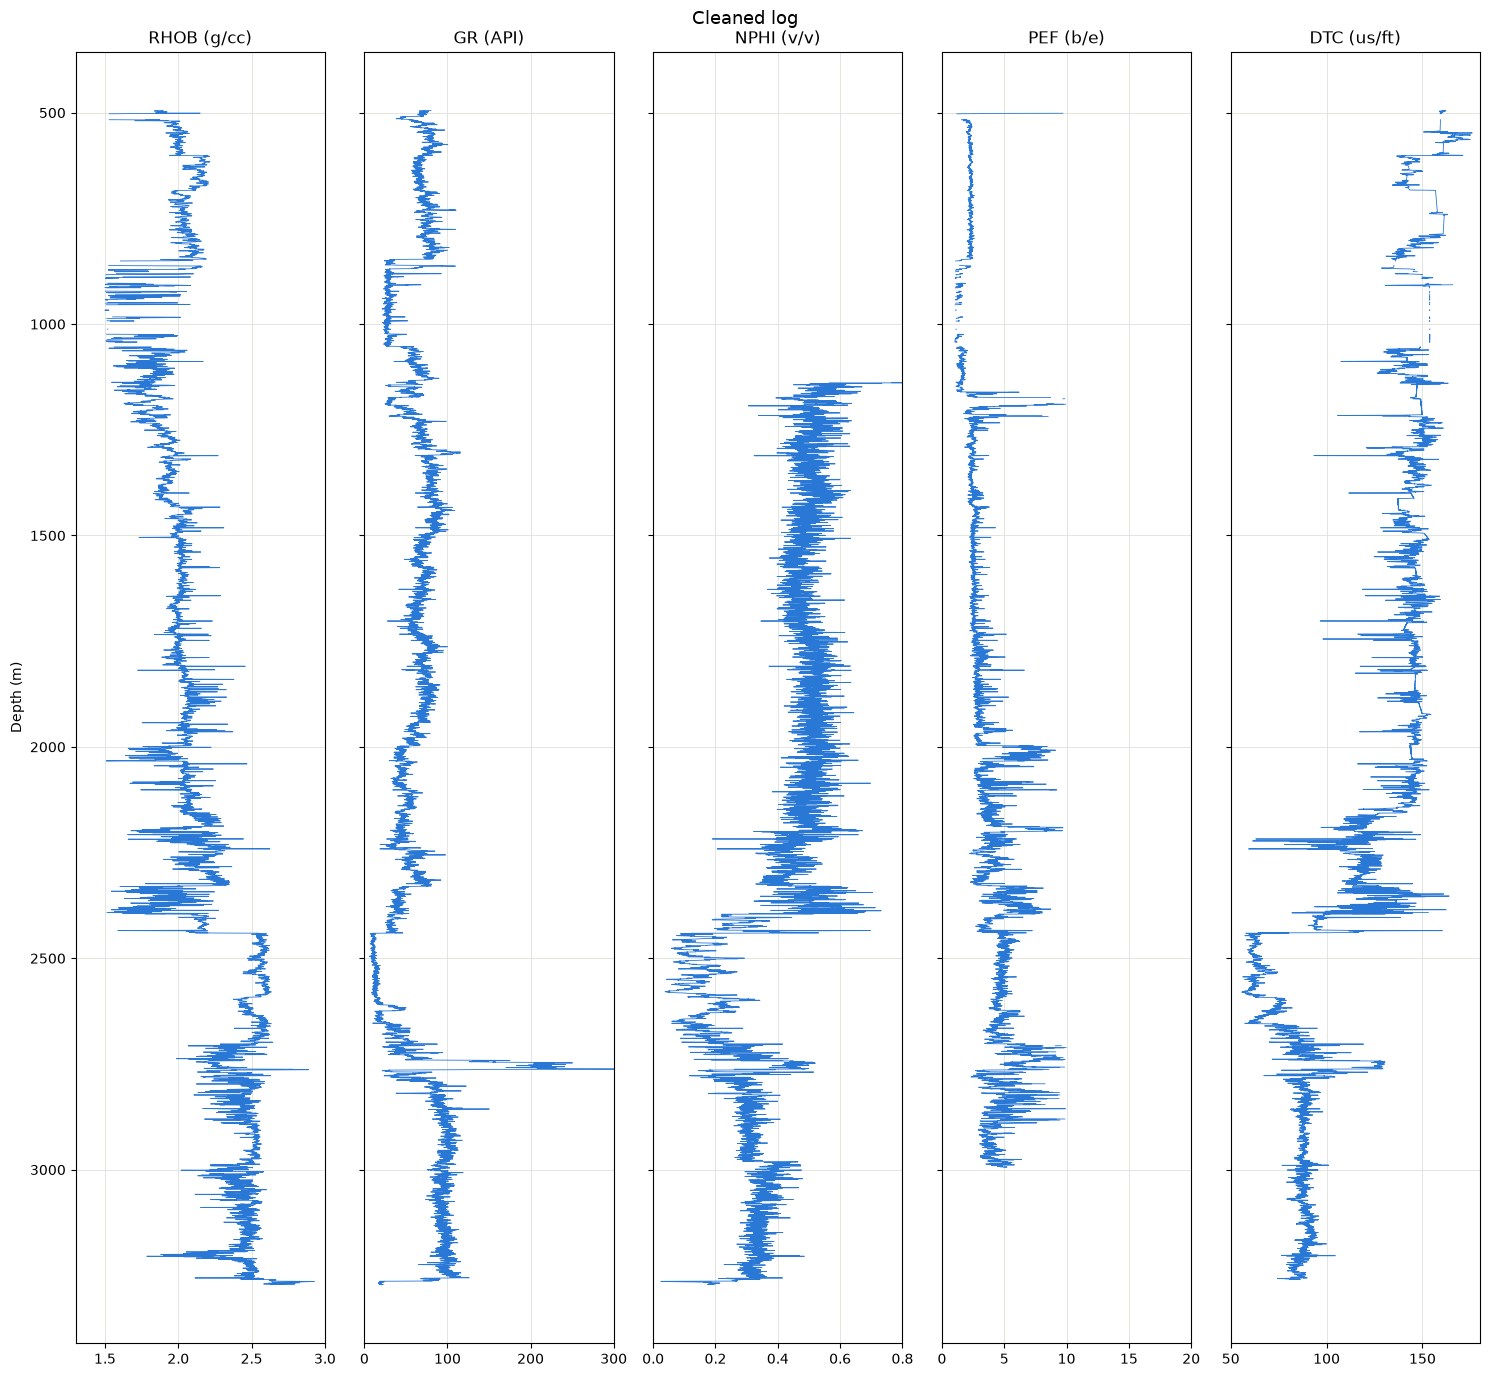

In [12]:
fig, axes = plt.subplots(1, len(curves), figsize=(15, 14), sharey=True)
for ax, col in zip(axes, curves):
    ax.plot(clean[col], clean["DEPTH_MD"], color="#2a78d6", linewidth=0.6)
    ax.set_xlim(track_range[col])
    ax.set_title(f"{col} ({units[col]})")
    ax.grid(color="#e1e0d9", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
fig.suptitle("Cleaned log", fontsize=13)
plt.tight_layout()
plt.show()


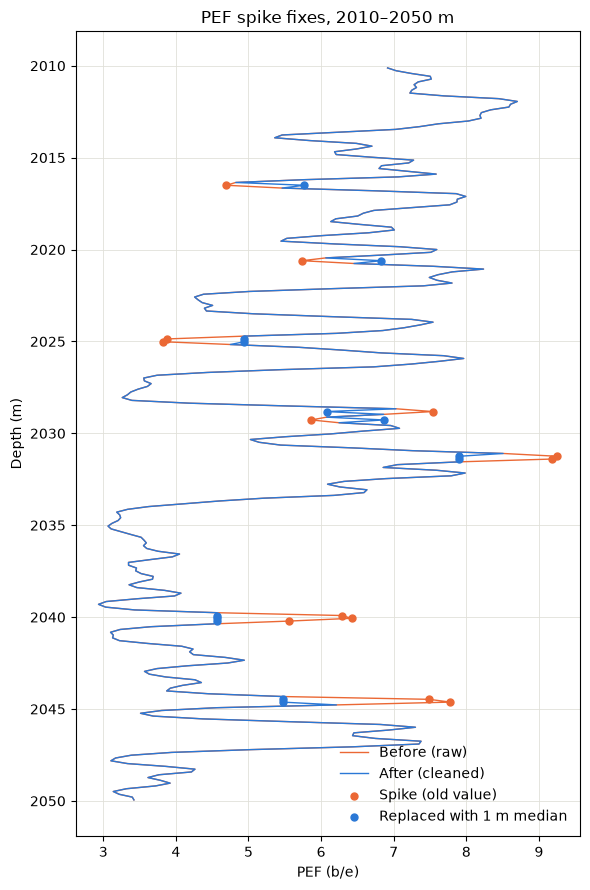

In [13]:
top, bottom = 2010, 2050
view = clean["DEPTH_MD"].between(top, bottom)
fixed = view & clean["flag_pef_spike"]

fig, ax = plt.subplots(figsize=(6, 9))
ax.plot(df.loc[view, "PEF"], df.loc[view, "DEPTH_MD"], color="#eb6834", linewidth=1, label="Before (raw)")
ax.plot(clean.loc[view, "PEF"], clean.loc[view, "DEPTH_MD"], color="#2a78d6", linewidth=1, label="After (cleaned)")
ax.scatter(df.loc[fixed, "PEF"], df.loc[fixed, "DEPTH_MD"], color="#eb6834", s=25, zorder=3, label="Spike (old value)")
ax.scatter(clean.loc[fixed, "PEF"], clean.loc[fixed, "DEPTH_MD"], color="#2a78d6", s=25, zorder=3, label="Replaced with 1 m median")
ax.invert_yaxis()
ax.set_xlabel("PEF (b/e)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"PEF spike fixes, {top}–{bottom} m")
ax.grid(color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


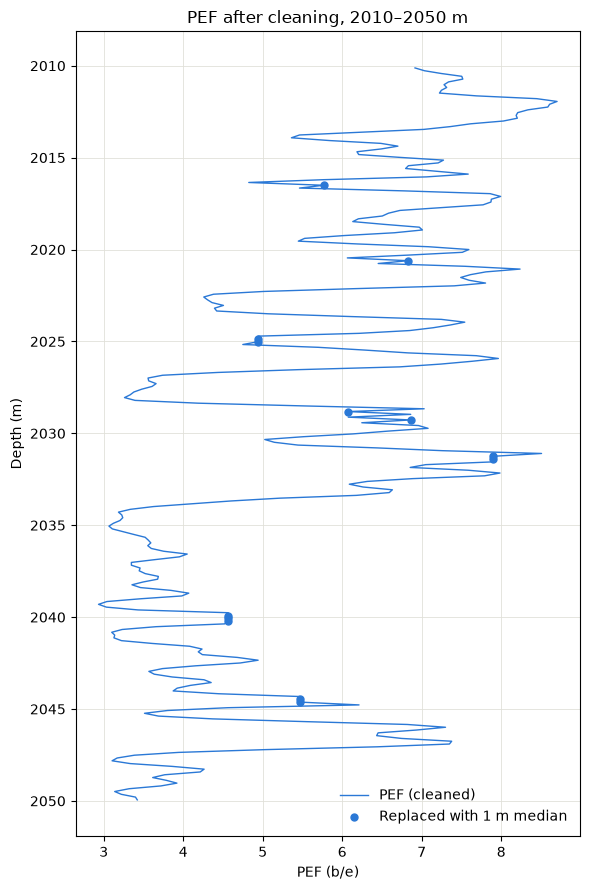

In [15]:
top, bottom = 2010, 2050
view = clean["DEPTH_MD"].between(top, bottom)
fixed = view & clean["flag_pef_spike"]

fig, ax = plt.subplots(figsize=(6, 9))
ax.plot(clean.loc[view, "PEF"], clean.loc[view, "DEPTH_MD"], color="#2a78d6", linewidth=1, label="PEF (cleaned)")
ax.scatter(clean.loc[fixed, "PEF"], clean.loc[fixed, "DEPTH_MD"], color="#2a78d6", s=25, zorder=3, label="Replaced with 1 m median")
ax.invert_yaxis()
ax.set_xlabel("PEF (b/e)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"PEF after cleaning, {top}–{bottom} m")
ax.grid(color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


In [16]:
changes = pd.DataFrame({
    "blanked": ((df[curves].notna()) & (clean[curves].isna())).sum(),
    "replaced": ((df[curves].notna()) & (clean[curves].notna()) & (df[curves] != clean[curves])).sum(),
    "flagged only": pd.Series({"RHOB": 0, "GR": int(clean["flag_gr_high"].sum()), "NPHI": 0,
                               "PEF": 0, "DTC": int(clean["flag_dtc_frozen"].sum())}),
})
changes["total readings"] = df[curves].notna().sum()
changes["% changed"] = ((changes["blanked"] + changes["replaced"]) / changes["total readings"] * 100).round(2)
changes


,blanked,replaced,flagged only,total readings,% changed
RHOB,976,0,0,18270,5.34
GR,0,0,9,18270,0.00
NPHI,0,0,0,14032,0.00
PEF,1203,206,0,16440,8.57
DTC,976,0,4846,18189,5.37


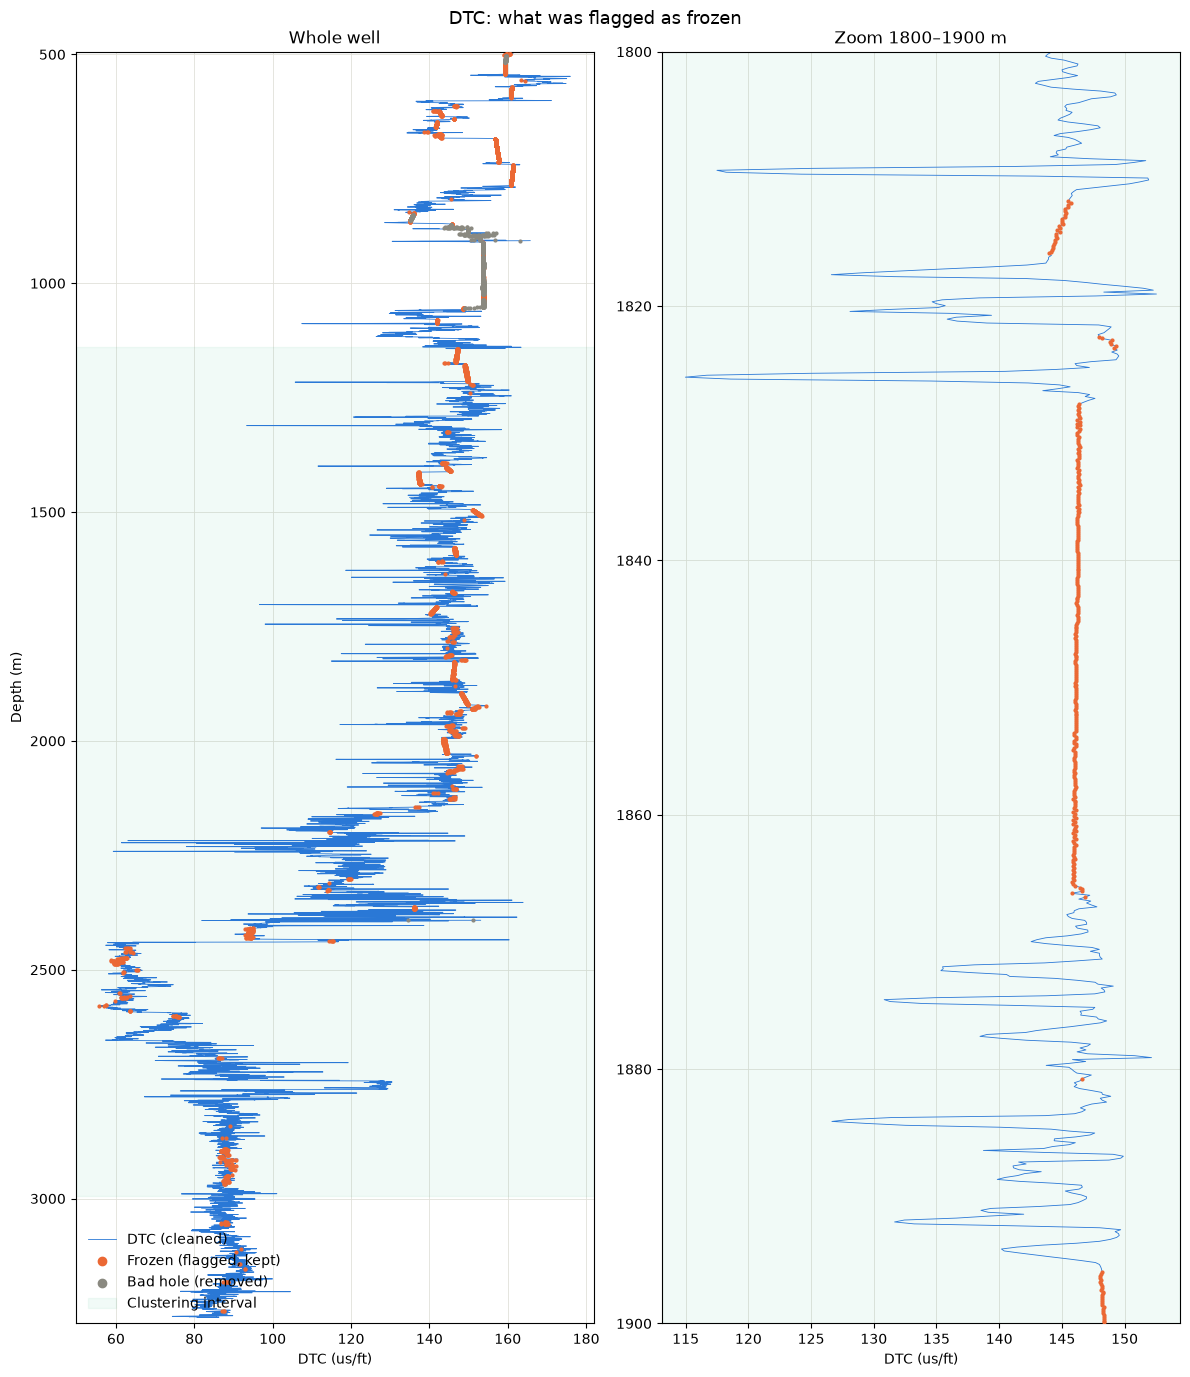

In [17]:
frozen = clean["flag_dtc_frozen"]
removed = clean["flag_bad_hole"]

fig, axes = plt.subplots(1, 2, figsize=(12, 14))
for ax, (name, top, bottom) in zip(axes, [("Whole well", 494, 3273), ("Zoom 1800–1900 m", 1800, 1900)]):
    view = clean["DEPTH_MD"].between(top, bottom)
    ax.plot(clean.loc[view, "DTC"], clean.loc[view, "DEPTH_MD"], color="#2a78d6", linewidth=0.6, label="DTC (cleaned)")
    ax.scatter(clean.loc[view & frozen, "DTC"], clean.loc[view & frozen, "DEPTH_MD"],
               color="#eb6834", s=4, zorder=3, label="Frozen (flagged, kept)")
    ax.scatter(df.loc[view & removed, "DTC"], df.loc[view & removed, "DEPTH_MD"],
               color="#8a8980", s=4, zorder=3, label="Bad hole (removed)")
    ax.axhspan(1138.7, 2993.9, color="#1baf7a", alpha=0.06, label="Clustering interval")
    ax.set_ylim(bottom, top)
    ax.set_xlabel("DTC (us/ft)")
    ax.set_title(name)
    ax.grid(color="#e1e0d9", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].legend(frameon=False, loc="lower left", markerscale=3)
fig.suptitle("DTC: what was flagged as frozen", fontsize=13)
plt.tight_layout()
plt.show()


In [18]:
after = pd.DataFrame({
    "count": clean[all_cols].count(),
    "missing": clean[all_cols].isna().sum(),
    "min": clean[all_cols].min().round(2),
    "median": clean[all_cols].median().round(2),
    "max": clean[all_cols].max().round(2),
    "std": clean[all_cols].std().round(2),
}).loc[all_cols]

pd.concat({"before": before[after.columns], "after": after}, axis=1)


before                                            after          \
          count missing     min   median      max     std  count missing   
DEPTH_MD  18270       0  494.53  1882.97  3272.02  801.94  18270       0   
RHOB      18270       0    1.40     2.06     2.93    0.30  17294     976   
GR        18270       0    6.19    66.78   499.02   28.64  18270       0   
NPHI      14032    4238    0.02     0.45     0.80    0.13  14032    4238   
PEF       16440    1830    1.01     2.79    66.03    2.56  15237    3033   
DTC       18189      81   55.73   141.30   175.95   30.62  17213    1057   

                                            
             min   median      max     std  
DEPTH_MD  494.53  1882.97  3272.02  801.94  
RHOB        1.50     2.07     2.93    0.26  
GR          6.19    66.78   499.02   28.64  
NPHI        0.02     0.45     0.80    0.13  
PEF         1.04     2.86     9.97    1.50  
DTC        55.73   140.07   175.95   30.73

In [19]:
clean.to_csv("force2020_cleaned.csv", index=False)

check = pd.read_csv("force2020_cleaned.csv")
print("Saved:", check.shape[0], "rows,", check.shape[1], "columns")
print(list(check.columns))


Saved: 18270 rows, 11 columns
['RHOB', 'GR', 'DEPTH_MD', 'NPHI', 'PEF', 'DTC', 'flag_bad_hole', 'flag_pef_high', 'flag_pef_spike', 'flag_dtc_frozen', 'flag_gr_high']
